# Phase 6 — Prediction & Batch Scoring Verification
Confirm single prediction and batch ranking work correctly,
and that fit_probability from predict.py aligns with the
model's behavior seen during evaluation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path("..")

from src.predict import TalentMatchPredictor
from src.preprocessing import load_candidates, load_jobs

candidates = load_candidates(ROOT / "data/raw/candidates.csv")
jobs       = load_jobs(ROOT / "data/raw/jobs.csv")

predictor = TalentMatchPredictor(threshold=0.40)

  [FeatureEngineer] Loaded ← G:\PROJECTS\TalentMatch-AI\models\feature_engineer_v1.joblib
  [TalentMatchPredictor] Model loaded, threshold=0.4


In [2]:
candidate = candidates.iloc[5]
job       = jobs.iloc[3]

print(predictor.skill_gap_report(candidate, job))

Candidate: Zara Williams (C0006)
Job: J004
Fit Score: 11.7% — Strong Poor Fit
Skills matched: 0/4
Missing skills (4): AWS, Hugging Face, Kubeflow, NumPy


In [3]:
job = jobs.iloc[0]
ranked = predictor.score_batch(candidates, job)

print(f"Job: {job['job_id']} — {job['title']} ({job['preferred_specialization']})")
print(f"Total candidates scored: {len(ranked)}")
print(f"\nTop 10 candidates:")
ranked[["rank", "candidate_name", "fit_percentage", "fit_verdict", "confidence_band"]].head(10)

Job: J001 — AI Research Engineer (Machine Learning)
Total candidates scored: 1000

Top 10 candidates:


,rank,candidate_name,fit_percentage,fit_verdict,confidence_band
0,1,Lin Anderson,99.0,Good Fit,Strong Fit
1,2,Amit Rodriguez,99.0,Good Fit,Strong Fit
2,3,Carlos Müller,98.7,Good Fit,Strong Fit
3,4,Yuki Williams,98.5,Good Fit,Strong Fit
4,5,Neha Liu,98.5,Good Fit,Strong Fit
5,6,Amit Martinez,98.4,Good Fit,Strong Fit
6,7,Kai Nair,98.4,Good Fit,Strong Fit
7,8,Amit Williams,98.3,Good Fit,Strong Fit
8,9,Neha Okonkwo,98.3,Good Fit,Strong Fit
9,10,Matthew Wilson,98.3,Good Fit,Strong Fit


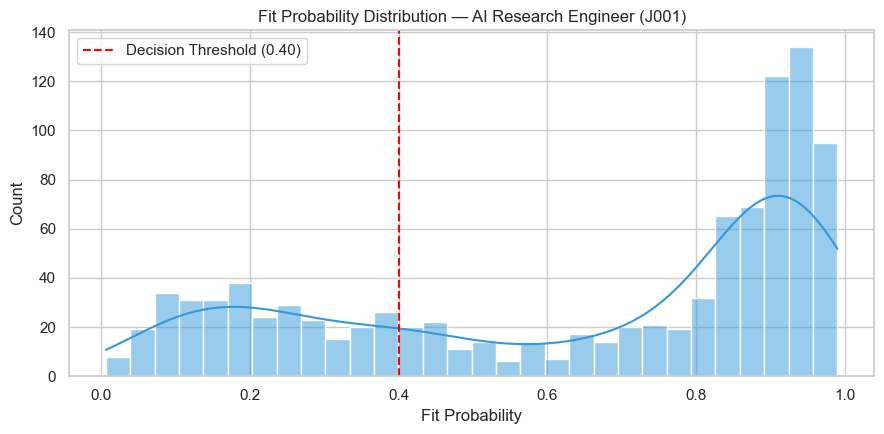

Good Fit  : 702 candidates
Poor Fit  : 298 candidates


In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(ranked["fit_probability"], bins=30, kde=True, ax=ax, color="#3498db")
ax.axvline(0.40, color="red", linestyle="--", label="Decision Threshold (0.40)")
ax.set_title(f"Fit Probability Distribution — {job['title']} ({job['job_id']})")
ax.set_xlabel("Fit Probability")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "screenshots/batch_scoring_distribution.png", dpi=150)
plt.show()

print(f"Good Fit  : {(ranked['fit_label']==1).sum()} candidates")
print(f"Poor Fit  : {(ranked['fit_label']==0).sum()} candidates")

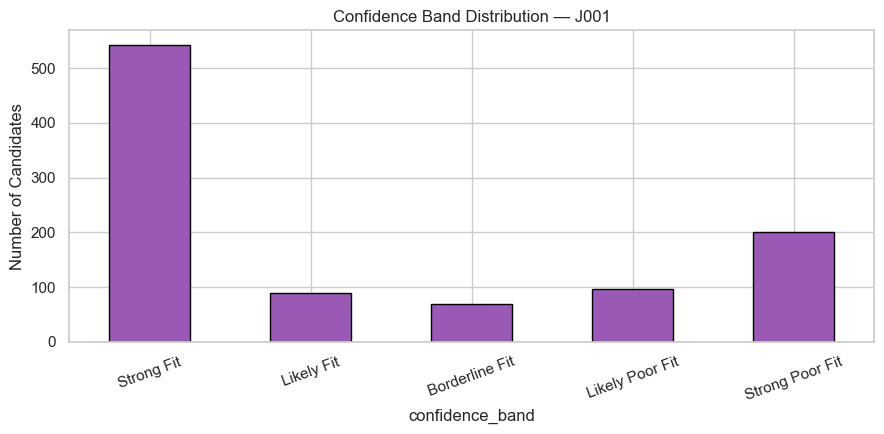

In [6]:
band_counts = ranked["confidence_band"].value_counts()
band_order = ["Strong Fit", "Likely Fit", "Borderline Fit", "Likely Poor Fit", "Strong Poor Fit"]
band_counts = band_counts.reindex(band_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 4.5))
band_counts.plot(kind="bar", ax=ax, color="#9b59b6", edgecolor="black")
ax.set_title(f"Confidence Band Distribution — {job['job_id']}")
ax.set_ylabel("Number of Candidates")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(ROOT / "screenshots/confidence_band_distribution.png", dpi=150)
plt.show()